# VitaGraph Tutorial

A guided walkthrough of the four building blocks of VitaGraph:

1. `SyntheticCohortGenerator` — synthetic tabular cohort data
2. `BioSignalProcessor` — synthetic per-person time series
3. `KnowledgeGraph` — typed graph over person/data/environment
4. `BioAgeEstimator` — regression on the synthetic `biological_age` label

> **Disclaimer:** every number in this notebook is synthetic, seeded
> random data. Nothing here is a real biological-age measurement or
> medical guidance — see `docs/METHODOLOGY.md`.

In [1]:
import pandas as pd

from vitagraph import (
    BioAgeEstimator,
    BioSignalProcessor,
    KnowledgeGraph,
    SyntheticCohortGenerator,
)
from vitagraph.synthetic_data import FEATURE_COLUMNS, TARGET_COLUMN

pd.set_option("display.precision", 2)


## 1. Generate a synthetic cohort

In [2]:
generator = SyntheticCohortGenerator(seed=42)
cohort = generator.generate(num_samples=500)
cohort.head()

,chronological_age,heart_rate_avg,hrv_avg,sleep_hours_avg,activity_level,environmental_exposure,biological_age
0,24.0,69.25,69.25,6.50,0.90,0.24,24.62
1,58.0,55.94,42.75,9.18,0.70,0.12,50.80
2,52.0,58.26,32.68,6.97,0.34,0.59,51.62
3,41.0,87.03,56.19,8.54,0.73,0.50,47.79
4,41.0,59.70,66.17,7.57,0.45,0.28,40.89


In [3]:
cohort.describe()

,chronological_age,heart_rate_avg,hrv_avg,sleep_hours_avg,activity_level,environmental_exposure,biological_age
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,44.46,69.64,55.04,7.43,0.58,0.41,46.31
std,14.28,8.17,11.94,1.04,0.19,0.20,14.91
min,20.00,46.28,11.22,4.54,0.00,0.00,15.64
25%,33.00,64.03,47.41,6.78,0.45,0.27,33.90
50%,44.00,69.88,55.33,7.46,0.60,0.40,46.55
75%,57.00,74.88,62.47,8.10,0.71,0.56,58.73
max,69.00,93.24,93.15,10.41,1.00,0.95,80.63


## 2. Train a biological-age estimator

In [4]:
from sklearn.model_selection import train_test_split

X, y = cohort[FEATURE_COLUMNS], cohort[TARGET_COLUMN]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

estimator = BioAgeEstimator(model_type="gradient_boosting")
estimator.train(X_train, y_train)
metrics = estimator.evaluate(X_test, y_test)
metrics

2026-07-18 13:22:41 | INFO     | vitagraph.bio_age_estimator | Training gradient_boosting on 400 samples (6 features)


2026-07-18 13:22:41 | INFO     | vitagraph.bio_age_estimator | Evaluation — MAE: 2.15  RMSE: 2.65  R²: 0.970


EvaluationMetrics(mae=2.1545, rmse=2.6455, r2=0.97)

In [5]:
estimator.feature_importance()

{'chronological_age': 0.9321277099810329,
 'heart_rate_avg': 0.03500756215638134,
 'sleep_hours_avg': 0.011513124413236943,
 'hrv_avg': 0.01112795116848168,
 'environmental_exposure': 0.006072003844438129,
 'activity_level': 0.004151648436429043}

## 3. Simulate raw biometric time series for one person

In [6]:
from datetime import datetime

processor = BioSignalProcessor(seed=42)
start = datetime(2026, 1, 1)

hr_df = processor.generate_synthetic_heart_rate(num_samples=48, start_time=start, interval_minutes=30)
sleep_df = processor.generate_synthetic_sleep_data(num_days=14, start_date=start.date())
hr_df.head()

,timestamp,heart_rate
0,2026-01-01 00:00:00,68
1,2026-01-01 00:30:00,57
2,2026-01-01 01:00:00,72
3,2026-01-01 01:30:00,73
4,2026-01-01 02:00:00,50


## 4. Build and inspect a knowledge graph

In [7]:
kg = KnowledgeGraph()
kg.build_from_processed_data("P001", hr_df, sleep_df)
kg.get_graph_info()

{'nodes': 63,
 'edges': 62,
 'node_type_counts': {'Person': 1, 'BiometricData': 62},
 'edge_relations': ['HAS_DATA']}

2026-07-18 13:22:42 | INFO     | vitagraph.visualization | Saved subgraph plot for P001 to outputs/tutorial_P001.png


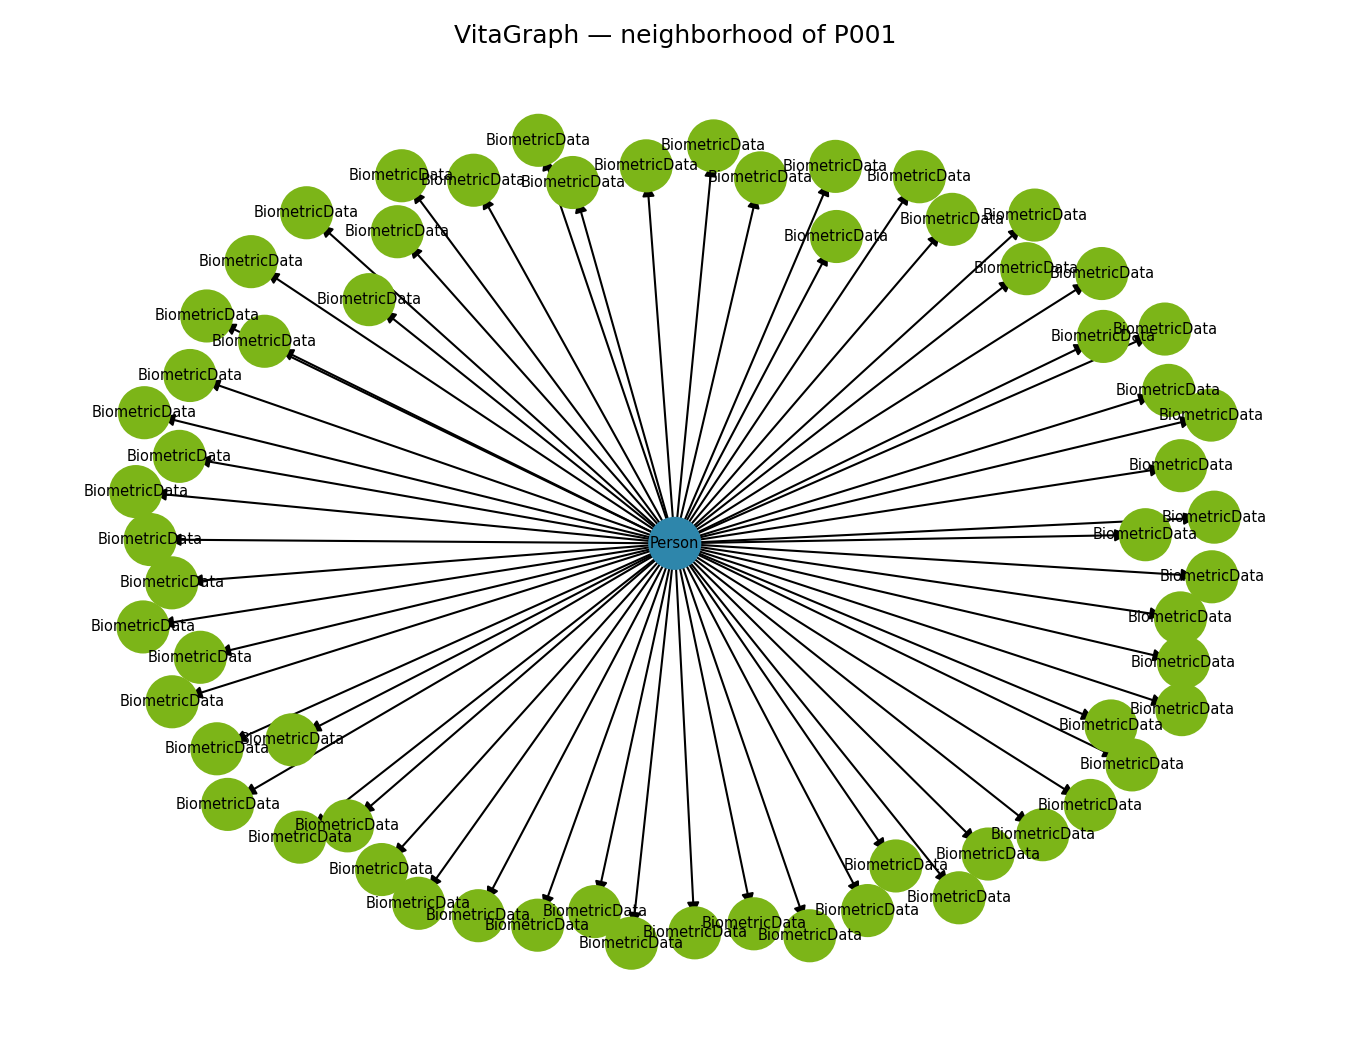

In [8]:
from IPython.display import Image

from vitagraph.visualization import plot_person_subgraph

plot_person_subgraph(kg, "P001", "outputs/tutorial_P001.png")
Image("outputs/tutorial_P001.png")

## Next steps

- See `notebooks/Research.ipynb` for cross-validation, model comparison,
  and a discussion of what this framework does *not* yet claim to do.
- See `notebooks/Examples.ipynb` for more end-to-end usage patterns
  mirroring the scripts in `examples/`.
- See `docs/METHODOLOGY.md` and `docs/ROADMAP.md` for scope and future work.